In [2]:
import pyproj
from pyproj import Proj
import numpy as np
import pandas as pd
from pyproj import Proj
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib as mpl
from  matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader
import geopandas as gpd 
import xarray as xr

C:\Users\x12la\AppData\Local\Temp\ipykernel_3308\3270233291.py:14: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [13]:
df1= pd.read_csv('USA_903_NOFILL.txt', skiprows=25, delimiter=r"\t", header=None) # MDV
df2 = pd.read_csv('USA_904_NOFILL.txt', skiprows=25, delimiter=r"\t", header=None) # HDV
df3 = pd.read_csv('Test/USA_306_FILL.txt', skiprows=25, delimiter=r"\t", header=None) # Med/High
df4 = pd.read_csv('Test/USA_205_NOFILL.txt', skiprows=25, delimiter=r"\t", header=None)  #extended idling

cols=['Surrogate Grid','FIPS','Col','Row','Frac','!','Numerator','Denom','QASUM']
df1.columns = cols
df2.columns = cols
df3.columns = cols
df4.columns = cols

C:\Users\x12la\AppData\Local\Temp\ipykernel_3308\1516516248.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df1= pd.read_csv('USA_903_NOFILL.txt', skiprows=25, delimiter=r"\t", header=None) # MDV
C:\Users\x12la\AppData\Local\Temp\ipykernel_3308\1516516248.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df2 = pd.read_csv('USA_904_NOFILL.txt', skiprows=25, delimiter=r"\t", header=None) # HDV
C:\Users\x12la\AppData\Local\Temp\ipykernel_3308\1516516248.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different 

In [14]:
# Get lat/lon from LADCO grid and find corners of domain
# this is to be used for map extents
grid='C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc'
cmaq_lon,cmaq_lat=np.array(Dataset(grid)['lon']),np.array(Dataset(grid)['lat'])
llat,ulat,llon,ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

midlat = ulat- (ulat - llat)
midlon =  ulon-(ulon - llon)
print(midlat, midlon)

40.210953 -90.07886


C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

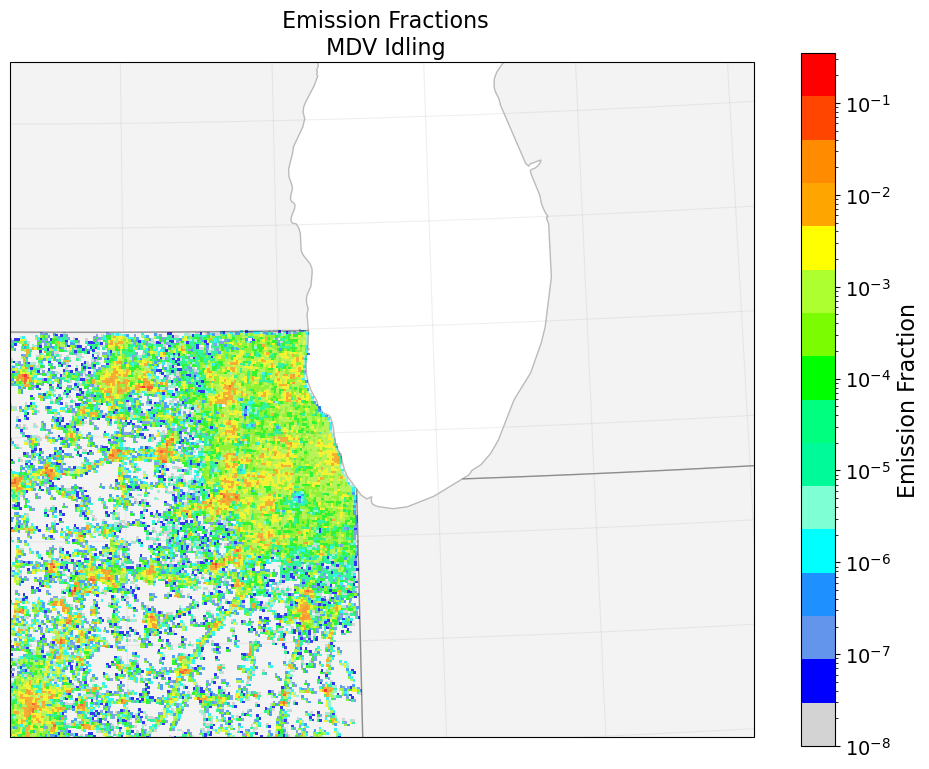

In [9]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df1)) ; lon= np.zeros(len(df1))
for i in range(len(df1)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df1['Col'][i])),(yorig + (ycell * df1['Row'][i])), inverse=True)
        
df1['lat'] = lat ; df1['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df1)):
    i,j =df1['Col'][x]-1, df1['Row'][x]-1  
    fraction[i,j] = df1.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n MDV Idling', fontsize=16)

# Show the plot
plt.show()
    

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

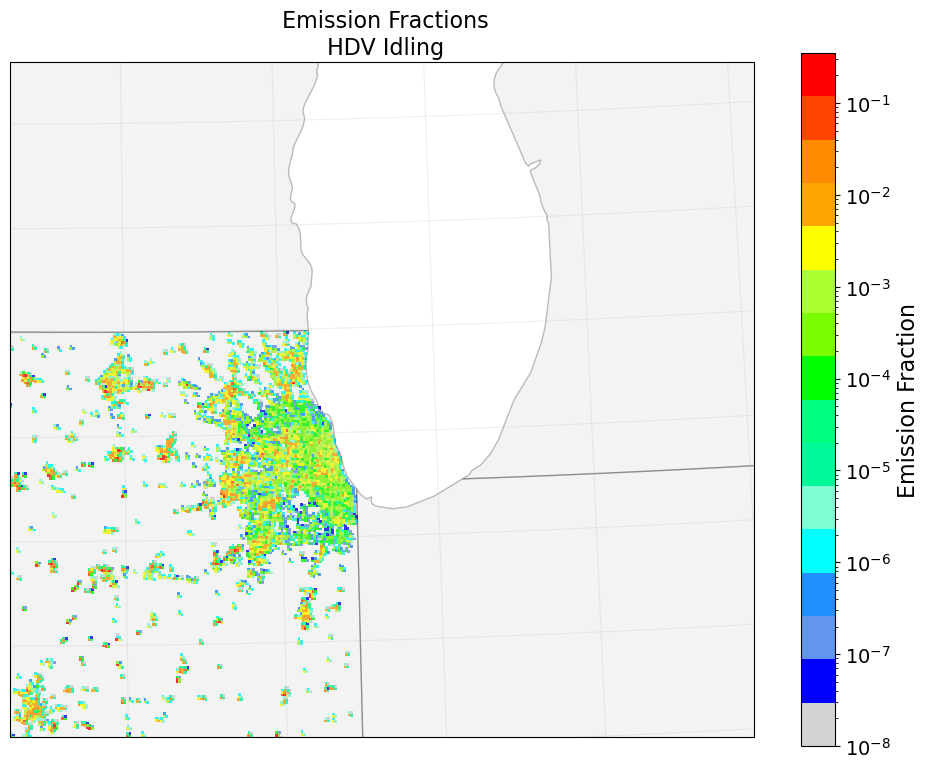

In [10]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df2)) ; lon= np.zeros(len(df2))
for i in range(len(df2)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df2['Col'][i])),(yorig + (ycell * df2['Row'][i])), inverse=True)
        
df2['lat'] = lat ; df2['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df2)):
    i,j =df2['Col'][x]-1, df2['Row'][x]-1  
    fraction[i,j] = df2.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n HDV Idling', fontsize=16)

# Show the plot
plt.show()

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

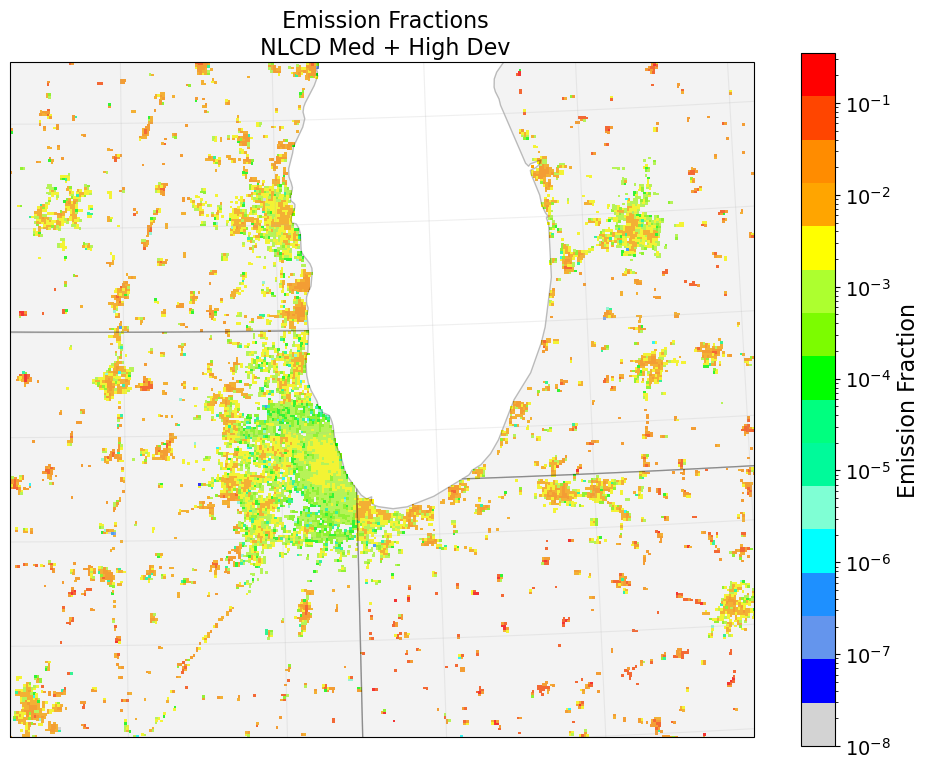

In [15]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df3)) ; lon= np.zeros(len(df3))
for i in range(len(df3)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df3['Col'][i])),(yorig + (ycell * df3['Row'][i])), inverse=True)
        
df3['lat'] = lat ; df3['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df3)):
    i,j =df3['Col'][x]-1, df3['Row'][x]-1  
    fraction[i,j] = df3.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n NLCD Med + High Dev', fontsize=16)

# Show the plot
plt.show()
    

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

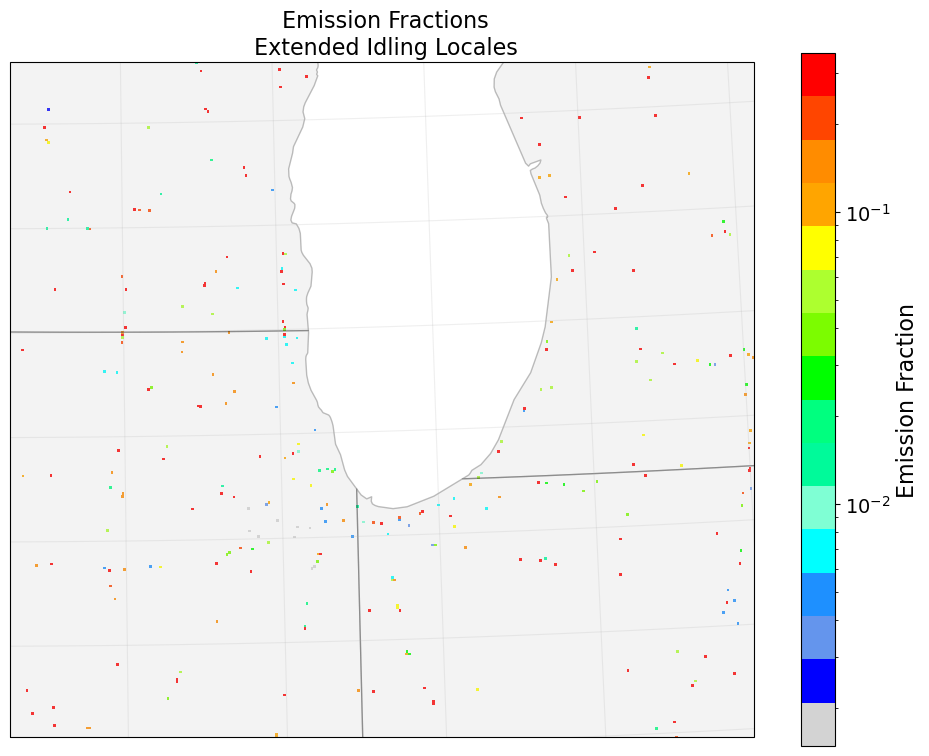

In [23]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df4)) ; lon= np.zeros(len(df4))
for i in range(len(df4)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df4['Col'][i])),(yorig + (ycell * df4['Row'][i])), inverse=True)
        
df4['lat'] = lat ; df4['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df4)):
    i,j =df4['Col'][x]-1, df4['Row'][x]-1  
    fraction[i,j] = df4.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n Extended Idling Locales', fontsize=16)

# Show the plot
plt.show()
    

<h1> Fill in WI, IN, and MI grid cells using Med/High Dev Intensity

In [24]:
df5 = df1.copy()
mask = df3['FIPS'].astype(str).str.zfill(5).str[:2] != '17'
df5 = pd.concat([df5, df3.loc[mask, df1.columns.intersection(df3.columns)].reindex(columns=df1.columns)], ignore_index=True)
df5['Surrogate Grid'] = 903

cols=['Surrogate Grid','FIPS','Col','Row','Frac','!','Numerator','Denom','QASUM']
df5 = df5[cols].copy()
df5['Surrogate Grid'] = df5['Surrogate Grid'].astype(int)
df5['FIPS']           = df5['FIPS'].astype(int)
df5['Col']            = df5['Col'].astype(int)
df5['Row']            = df5['Row'].astype(int)
df5['Frac']           = df5['Frac'].astype(float)

orig_path = 'USA_903_NOFILL.txt'
with open(orig_path, 'r', encoding='utf-8', newline='') as f:
    header_lines = [next(f).rstrip('\n') for _ in range(25)]

out_path = 'FinalSurrogates/USA_903_NOFILL.txt'
with open(out_path, 'w', encoding='utf-8', newline='\n') as f:
    f.write('\n'.join(header_lines) + '\n')
    df5.to_csv(f, sep='\t', header=False, index=False, float_format='%.6g')   

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

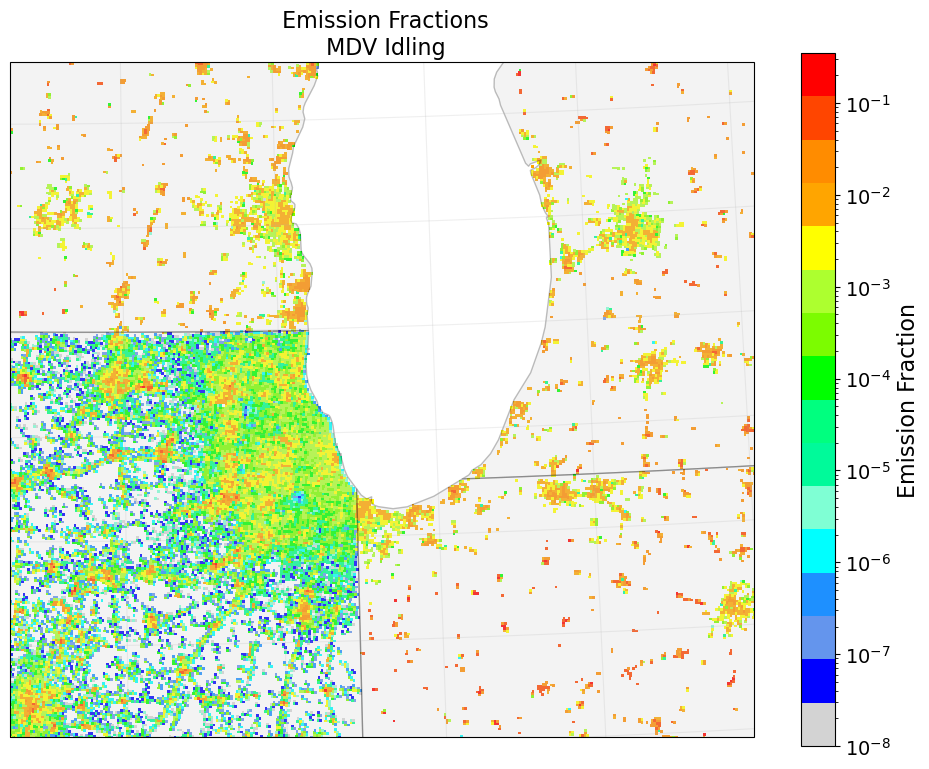

In [25]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df5)) ; lon= np.zeros(len(df5))
for i in range(len(df5)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df5['Col'][i])),(yorig + (ycell * df5['Row'][i])), inverse=True)
        
df5['lat'] = lat ; df5['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df5)):
    i,j =df5['Col'][x]-1, df5['Row'][x]-1  
    fraction[i,j] = df5.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n MDV Idling', fontsize=16)

# Show the plot
plt.show()
    

In [19]:
df6 = df2.copy()
mask = df3['FIPS'].astype(str).str.zfill(5).str[:2] != '17'
df6 = pd.concat(
    [df6, df3.loc[mask, df2.columns.intersection(df3.columns)].reindex(columns=df2.columns)],
    ignore_index=True
)
df6['Surrogate Grid'] = 904

cols=['Surrogate Grid','FIPS','Col','Row','Frac','!','Numerator','Denom','QASUM']
df6 = df6[cols].copy()
df6['Surrogate Grid'] = df6['Surrogate Grid'].astype(int)
df6['FIPS']           = df6['FIPS'].astype(int)
df6['Col']            = df6['Col'].astype(int)
df6['Row']            = df6['Row'].astype(int)
df6['Frac']           = df6['Frac'].astype(float)

orig_path = 'USA_904_NOFILL.txt'
with open(orig_path, 'r', encoding='utf-8', newline='') as f:
    header_lines = [next(f).rstrip('\n') for _ in range(25)]

out_path = 'FinalSurrogates/USA_904_NOFILL.txt'
with open(out_path, 'w', encoding='utf-8', newline='\n') as f:
    f.write('\n'.join(header_lines) + '\n')
    df6.to_csv(f, sep='\t', header=False, index=False, float_format='%.6g')   

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

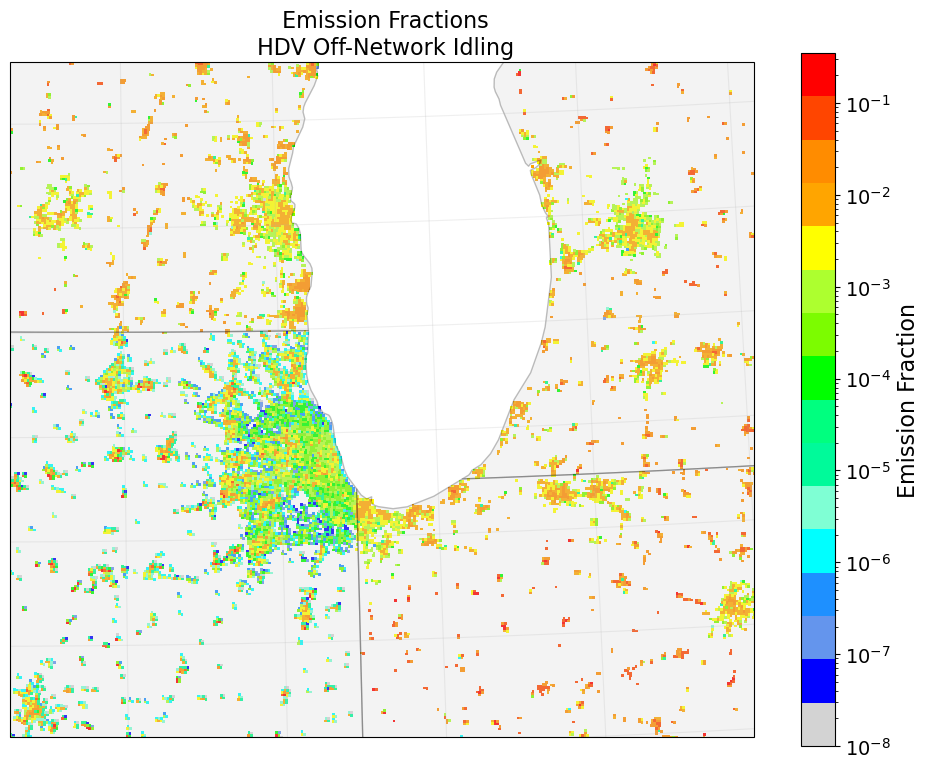

In [20]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df6)) ; lon= np.zeros(len(df6))
for i in range(len(df6)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df6['Col'][i])),(yorig + (ycell * df6['Row'][i])), inverse=True)
        
df6['lat'] = lat ; df6['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df6)):
    i,j =df6['Col'][x]-1, df6['Row'][x]-1  
    fraction[i,j] = df6.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n HDV Off-Network Idling', fontsize=16)

# Show the plot
plt.show()
    

In [21]:
df7 = df2.copy()
mask = df4['FIPS'].astype(str).str.zfill(5).str[:2] != '17'
add_rows = df4.loc[mask, df2.columns.intersection(df4.columns)].reindex(columns=df2.columns).copy()
df7 = pd.concat([df7, add_rows], ignore_index=True)
df7['Surrogate Grid'] = 905

cols=['Surrogate Grid','FIPS','Col','Row','Frac','!','Numerator','Denom','QASUM']
df7 = df7[cols].copy()
df7['Surrogate Grid'] = df7['Surrogate Grid'].astype(int)
df7['FIPS']           = df7['FIPS'].astype(int)
df7['Col']            = df7['Col'].astype(int)
df7['Row']            = df7['Row'].astype(int)
df7['Frac']           = df7['Frac'].astype(float)

orig_path = 'FinalSurrogates/USA_905_NOFILL.txt'
with open(orig_path, 'r', encoding='utf-8', newline='') as f:
    header_lines = [next(f).rstrip('\n') for _ in range(25)]

out_path = 'FinalSurrogates/USA_905_NOFILL.txt'
with open(out_path, 'w', encoding='utf-8', newline='\n') as f:
    f.write('\n'.join(header_lines) + '\n')
    df7.to_csv(f, sep='\t', header=False, index=False, float_format='%.6g')   

C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1785: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
C:\Users\x12la\anaconda3\lib\site-packages\cartopy\mpl\gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecat

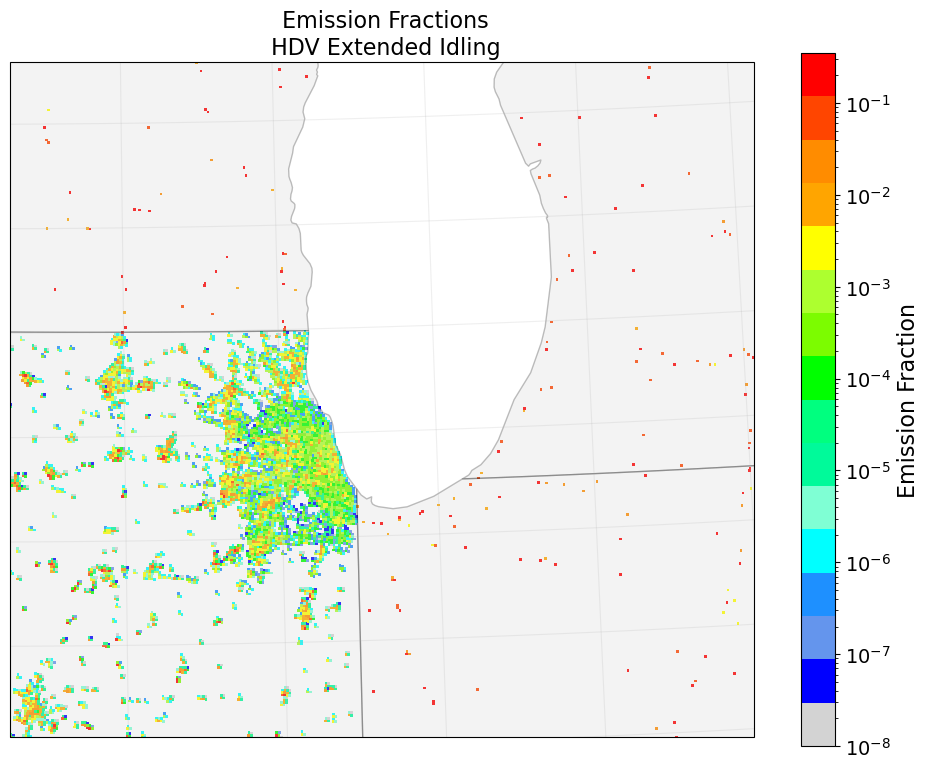

In [22]:
#projection input from first line of surrogate file "GRID... ""
# variables are listed in order they appear on the first line 
xorig= -132000  #lower left ref
yorig= -420000   # lower left ref
ycell= 1333.33  # meters
xcell= 1333.33   # meters 
cols= 1260   
rows= 1170
# Lambert proj
palp= 33. # 1st par lat
pbet= 45. # 2nd par lat
xcent= -97.  # center lon
# -97 repeats for some reason -not sure why 
ycent= 40     # center lat

#find Lambert projection given projection details, find lat/lon boundaries using pyproj Proj package
# https://proj.org/    Documentation on the package itself
# https://proj.org/operations/projections/lcc.html  #Documentation on using Proj for LCC projections
proj_trans = Proj(proj='lcc', lat_1=palp, lat_2=pbet, lon_0=xcent, lat_0=ycent, a=6370000.0, b=6370000.0)
# lower left corner of grid
lonO, latO = proj_trans(xorig, yorig, inverse=True)
# Upper right corner of grid 
lonE, latE = proj_trans((xorig + (xcell * cols)),(yorig + (ycell * rows)), inverse=True)

# Convert row/col to lon/lat using defined projection 
lat= np.zeros(len(df7)) ; lon= np.zeros(len(df7))
for i in range(len(df7)): 
    lon[i], lat[i]= proj_trans((xorig + (xcell * df7['Col'][i])),(yorig + (ycell * df7['Row'][i])), inverse=True)
        
df7['lat'] = lat ; df7['lon']= lon

#set up empty numpy arrays- we want to leave missing lat/lon data empty not zeros
longitude = np.empty((cols,rows)) ; latitude = np.empty((cols,rows))

#Create 2d arrays by looping through rows/cols to find lat/lon 
for i in range(cols): 
    for j in range(rows):
        longitude[i,j], latitude[i,j]= proj_trans((xorig + (xcell * i)),(yorig + (ycell * j)), inverse=True)
        
# set up empty 2d array for fraction value
fraction = np.empty((cols,rows))

# Find i,j index 
for x in range(len(df7)):
    i,j =df7['Col'][x]-1, df7['Row'][x]-1  
    fraction[i,j] = df7.Frac[x] 
    
# Set up figure to plot 
fig = plt.figure(figsize=(12, 10))

# Define colorbar colors to match LADCOS surrogate plots
# https://www.ladco.org/technical/modeling-results/ladco-2016-modeling/#Emissions/Surrogates/LADCO1_1260x1170
cmap = mpl.colors.ListedColormap(['lightgrey', 'blue', 'cornflowerblue', 'dodgerblue', 'cyan', 'aquamarine', 'mediumspringgreen', 'springgreen', 'lime', 'lawngreen', 'greenyellow', 'yellow', 'orange', 'darkorange', 'orangered', 'red'])

# Set up grid projection and axis extent
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=midlon, central_latitude=midlat))
ax.set_extent([np.amin(cmaq_lon) + 0.35, np.amax(cmaq_lon) - 0.55, np.amin(cmaq_lat) + 0.355, np.amax(cmaq_lat) - 0.35])
#ax.set_extent([-87.5, -87.8, 41.7, 42])
# Plot surrogates and colorbar, convert to PlateCarree projection to match LADCO, use log-normal colorbar
pcm = plt.pcolormesh(longitude, latitude, fraction, transform=ccrs.PlateCarree(), cmap=cmap, norm=mpl.colors.LogNorm(vmax=0.35))
cbar = plt.colorbar(pcm, label='Emission Fraction', shrink=0.9)  # Shrink the colorbar by 25%

# Set font size for colorbar label
cbar.ax.set_ylabel('Emission Fraction', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Add state boundaries and lat/lon labels 
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', alpha=0.25, facecolor='lightgrey')
gl = ax.gridlines(draw_labels=True, transform=ccrs.PlateCarree(), alpha=0.2, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# Turn off latitude and longitude ticks
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = False
gl.ylabels_left = False

ax.set_title(' Emission Fractions\n HDV Extended Idling', fontsize=16)

# Show the plot
plt.show()
    